# Fase 4 — Análisis de desempeño y reentrenamiento
## IgnisAI · Proyecto de Datos I · UCM

Este notebook cubre los apartados **1.1 y 1.3** del enunciado de la Fase 4:

- **1.1** Cargar el modelo reentrenado con todos los datos de fase 3 y analizar sus variables más importantes
- **1.3** Evaluar el modelo sobre los nuevos datos de 2026, analizar diferencias y estudiar el modelo FRP

Todos los datos y modelos se cargan directamente desde MinIO. No se necesita nada en local.


## 0. Imports y configuración

In [1]:
import sys
sys.path.append("src")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    fbeta_score, precision_score, recall_score, roc_auc_score,
    ConfusionMatrixDisplay
)
from extraccion import minioFunctions as mf
from modelos.utils.metricas import evaluar_clasificacion

# Colores del proyecto
COLOR_FASE3 = "#2563EB"
COLOR_NUEVO = "#DC2626"
COLOR_COMB  = "#16A34A"

# Hiperparámetros del mejor run (sweep: 3pdmt88q, run: v5cmrozh)
MEJORES_HIPERPARAMETROS = {
    "n_estimators":    2000,
    "learning_rate":   0.17971228299068043,
    "max_depth":       4,
    "subsample":       0.8142987782803428,
    "colsample_bytree": 0.8311621901655458,
    "min_child_weight": 1,
    "gamma":           0,
}
UMBRAL = 0.35189353387841105
SEED   = 42
COLS_ELIMINAR    = ["porcentaje", "temp_max", "temp_min", "NDVI", "pressure_mean"]
COLS_NO_FEATURES = ["final", "date", "_year"]

# Métricas de test de fase 3 (de la memoria)
METRICAS_FASE3_MEMORIA = {
    "accuracy":  0.9547,
    "f1":        0.3724,
    "f2":        0.3775,
    "precision": 0.3641,
    "recall":    0.3810,
}

print("Imports OK")


Imports OK


## 1. Carga de datos desde MinIO

In [2]:
cliente = mf.crear_cliente()

# Dataset fase 3
print("Descargando MINI.parquet (fase 3)...")
df_fase3 = mf.bajar_fichero(cliente, "grupo3/cleaned/MINI.parquet")
df_fase3["date"] = pd.to_datetime(df_fase3["date"])
print(f"  → {df_fase3.shape[0]:,} registros | {df_fase3['final'].sum():,} incendios ({df_fase3['final'].mean()*100:.2f}%)")

# Dataset nuevos 2026
print("\nDescargando final_cleaned_2026.parquet...")
df_nuevos = mf.bajar_fichero(cliente, "grupo3/cleaned/final_cleaned_2026.parquet")
df_nuevos["date"] = pd.to_datetime(df_nuevos["date"])
print(f"  → {df_nuevos.shape[0]:,} registros | {df_nuevos['final'].sum():,} incendios ({df_nuevos['final'].mean()*100:.2f}%)")

print("\nDatos cargados correctamente")


Descargando MINI.parquet (fase 3)...
Dataframe MINI.parquet importado correctamente
  → 73,324 registros | 2,026 incendios (2.76%)

Descargando final_cleaned_2026.parquet...
Dataframe final_cleaned_2026.parquet importado correctamente
  → 550 registros | 22 incendios (4.00%)

Datos cargados correctamente


## 2. Preparación de features

In [3]:
def preparar_X_y(df):
    df2 = df.drop(columns=COLS_ELIMINAR, errors="ignore")
    y = df2["final"]
    X = df2.drop(columns=[c for c in COLS_NO_FEATURES if c in df2.columns], errors="ignore")
    return X, y

X_fase3, y_fase3 = preparar_X_y(df_fase3)
X_nuevos, y_nuevos = preparar_X_y(df_nuevos)

# Alinear columnas
cols_comunes = [c for c in X_fase3.columns if c in X_nuevos.columns]
X_fase3  = X_fase3[cols_comunes]
X_nuevos = X_nuevos[cols_comunes]

print(f"Features usadas ({len(cols_comunes)}): {cols_comunes}")


Features usadas (18): ['lat', 'lon', 'soil_temp', 'elevacion_centro', 'grados', 'temp_mean', 'humidity_mean', 'precipitation', 'wind_speed_max', 'wind_gusts_max', 'cloud_cover', 'radiation', 'evapotranspiration', 'sunshine_seconds', 'NDWI', 'dist_civ', 'dia_sin', 'dia_cos']


## 3. Apartado 1.1 — Carga del modelo de clasificación desde MinIO

El modelo ya fue entrenado con todos los datos de fase 3 y subido a MinIO mediante el script `reentrenamiento_final.py`.
Aquí simplemente lo cargamos para el análisis.


In [4]:
# Cargar modelo de clasificación desde MinIO
import io

print("Cargando modelo XGBoost clasificación desde MinIO...")
response = cliente.get_object("pd1", "grupo3/modelos/xgboost_clasificacion_2026.pkl")
buffer_clf = io.BytesIO(response.read())
response.close()
clf_fase3 = joblib.load(buffer_clf)
print("Modelo cargado correctamente")
print(f"   Tipo: {type(clf_fase3).__name__}")
print(f"   N estimators: {clf_fase3.n_estimators}")


Cargando modelo XGBoost clasificación desde MinIO...
Modelo cargado correctamente
   Tipo: XGBClassifier
   N estimators: 2000


## 4. Apartado 1.3 — Evaluación sobre los nuevos datos de 2026

Se evalúa el modelo entrenado con fase 3 sobre los **550 registros nuevos de 2026**
que no participaron en el entrenamiento. Esta es la evaluación real del modelo en producción.


In [5]:
def evaluar_modelo(clf, X, y, nombre, umbral=UMBRAL):
    y_prob = clf.predict_proba(X)[:, 1]
    y_pred = (y_prob >= umbral).astype(int)
    metricas = {
        "accuracy":  round(accuracy_score(y, y_pred), 4),
        "f1":        round(f1_score(y, y_pred, zero_division=0), 4),
        "f2":        round(fbeta_score(y, y_pred, beta=2, zero_division=0), 4),
        "precision": round(precision_score(y, y_pred, zero_division=0), 4),
        "recall":    round(recall_score(y, y_pred, zero_division=0), 4),
        "auc_roc":   round(roc_auc_score(y, y_prob), 4),
    }
    cm = confusion_matrix(y, y_pred)
    print(f"\n{'='*50}")
    print(f"MÉTRICAS — {nombre}")
    print(f"{'='*50}")
    for k, v in metricas.items():
        print(f"  {k:<12}: {v}")
    print(f"\n  Matriz de confusión:")
    print(f"    TN={cm[0,0]}  FP={cm[0,1]}")
    print(f"    FN={cm[1,0]}  TP={cm[1,1]}")
    return metricas, cm, y_prob, y_pred

metricas_nuevos, cm_nuevos, y_prob_nuevos, y_pred_nuevos = evaluar_modelo(
    clf_fase3, X_nuevos, y_nuevos, "Modelo fase 3 — datos nuevos 2026"
)



MÉTRICAS — Modelo fase 3 — datos nuevos 2026
  accuracy    : 0.9927
  f1          : 0.9167
  f2          : 0.9649
  precision   : 0.8462
  recall      : 1.0
  auc_roc     : 1.0

  Matriz de confusión:
    TN=524  FP=4
    FN=0  TP=22


### 4.1 Comparativa con métricas de test de fase 3

Métrica       Fase 3 (test)   Datos 2026   Diferencia
----------------------------------------------------
accuracy             0.9547       0.9927 +      0.038
f1                   0.3724       0.9167 +     0.5443
f2                   0.3775       0.9649 +     0.5874
precision            0.3641       0.8462 +     0.4821
recall                0.381          1.0 +      0.619


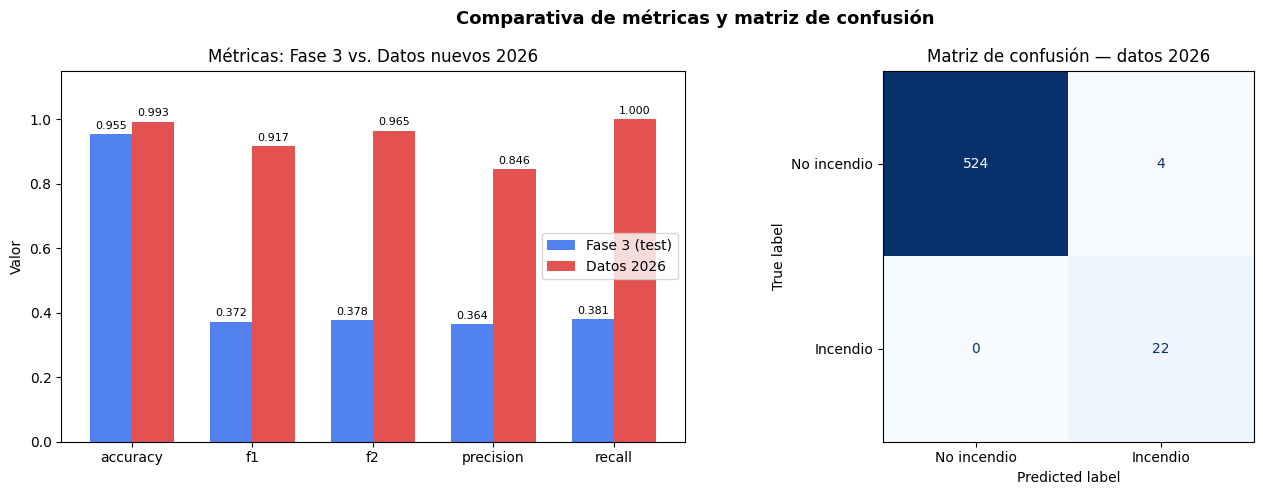

In [6]:
metricas_labels = ["accuracy", "f1", "f2", "precision", "recall"]
v_mem   = [METRICAS_FASE3_MEMORIA[m] for m in metricas_labels]
v_nuevo = [metricas_nuevos[m] for m in metricas_labels]

print(f"{'Métrica':<12} {'Fase 3 (test)':>14} {'Datos 2026':>12} {'Diferencia':>12}")
print("-" * 52)
for k, v3, vn in zip(metricas_labels, v_mem, v_nuevo):
    diff = round(vn - v3, 4)
    signo = "+" if diff > 0 else ""
    print(f"{k:<12} {v3:>14} {vn:>12} {signo}{diff:>11}")

# Gráfica
x = np.arange(len(metricas_labels))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparativa de métricas y matriz de confusión", fontsize=13, fontweight="bold")

ax = axes[0]
b3 = ax.bar(x - w/2, v_mem,   width=w, label="Fase 3 (test)",   color=COLOR_FASE3, alpha=0.8)
bn = ax.bar(x + w/2, v_nuevo, width=w, label="Datos 2026",       color=COLOR_NUEVO, alpha=0.8)
for bar in list(b3) + list(bn):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(metricas_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Valor")
ax.set_title("Métricas: Fase 3 vs. Datos nuevos 2026")
ax.legend()

ax = axes[1]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nuevos, display_labels=["No incendio", "Incendio"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de confusión — datos 2026")

plt.tight_layout()
plt.savefig("resultados_fase4_metricas.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.2 Análisis de distribuciones — Variable objetivo y variables clave

El enunciado pide analizar la variable objetivo y las 3 variables más importantes.
Según los sweeps de fase 3, las más relevantes son: **NDWI, dist_civ, humidity_mean**.


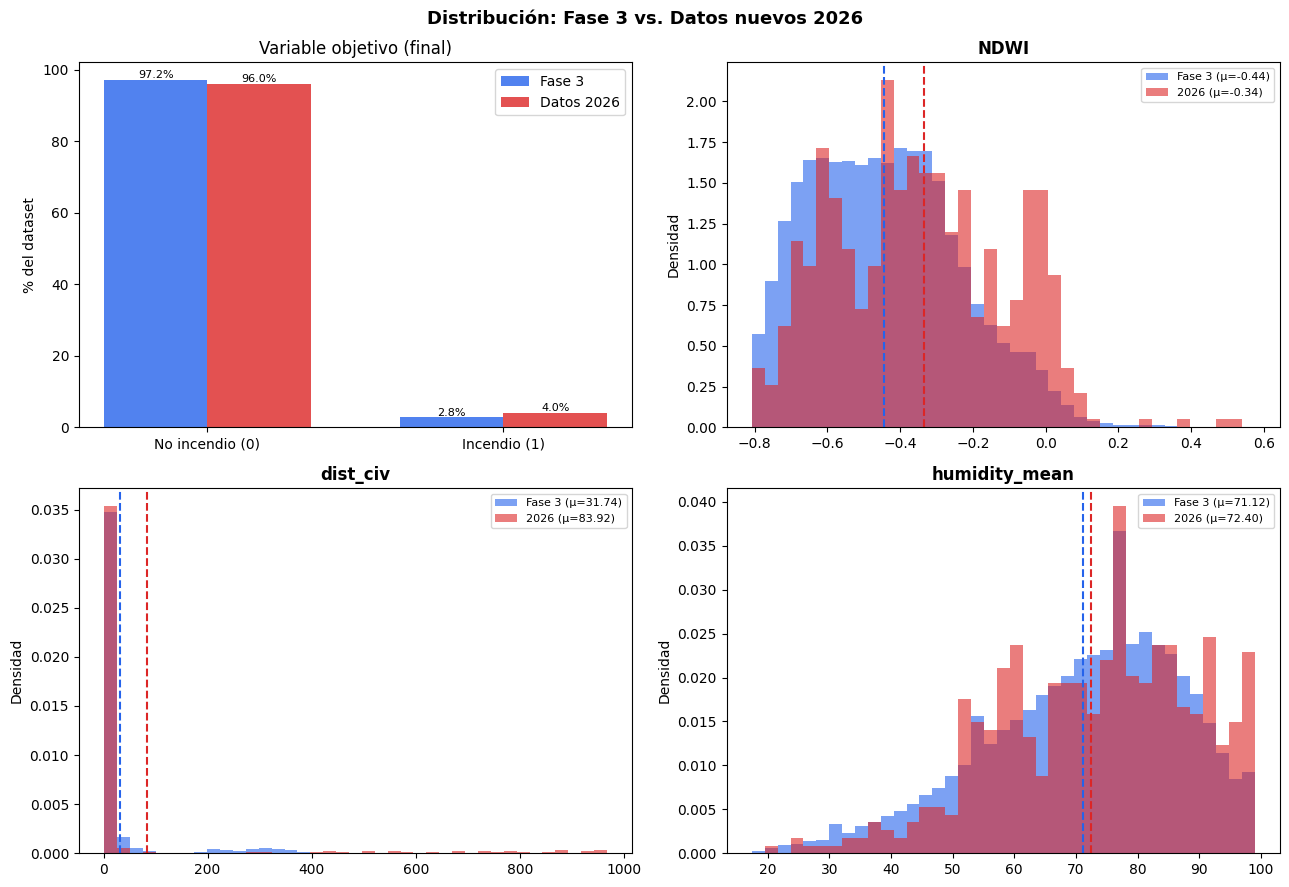


Estadísticos comparativos:
Variable         Fase3 media   2026 media    Fase3 std     2026 std
-----------------------------------------------------------------
final                  0.028        0.040        0.164        0.196
NDWI                  -0.444       -0.335        0.209        0.261
dist_civ              31.738       83.916       77.406      223.852
humidity_mean         71.119       72.398       15.984       17.005


In [7]:
VARS_ANALIZAR = ["NDWI", "dist_civ", "humidity_mean"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Distribución: Fase 3 vs. Datos nuevos 2026", fontsize=13, fontweight="bold")
axes_flat = axes.flatten()

# Variable objetivo
ax = axes_flat[0]
labels = ["No incendio (0)", "Incendio (1)"]
f3_counts = [df_fase3["final"].value_counts().get(0,0), df_fase3["final"].value_counts().get(1,0)]
n26_counts = [df_nuevos["final"].value_counts().get(0,0), df_nuevos["final"].value_counts().get(1,0)]
f3_pct  = [c/sum(f3_counts)*100 for c in f3_counts]
n26_pct = [c/sum(n26_counts)*100 for c in n26_counts]
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, f3_pct,  width=w, label="Fase 3",       color=COLOR_FASE3, alpha=0.8)
ax.bar(x + w/2, n26_pct, width=w, label="Datos 2026",   color=COLOR_NUEVO, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("% del dataset")
ax.set_title("Variable objetivo (final)")
ax.legend()
for i, (p3, pn) in enumerate(zip(f3_pct, n26_pct)):
    ax.text(i - w/2, p3 + 0.5, f"{p3:.1f}%", ha="center", fontsize=8)
    ax.text(i + w/2, pn + 0.5, f"{pn:.1f}%", ha="center", fontsize=8)

# Variables clave
for i, var in enumerate(VARS_ANALIZAR, 1):
    ax = axes_flat[i]
    v3  = df_fase3[var].dropna()
    vn  = df_nuevos[var].dropna()
    xmin = min(v3.quantile(0.01), vn.quantile(0.01))
    xmax = max(v3.quantile(0.99), vn.quantile(0.99))
    bins = np.linspace(xmin, xmax, 40)
    ax.hist(v3, bins=bins, color=COLOR_FASE3, alpha=0.6, density=True, label=f"Fase 3 (μ={v3.mean():.2f})")
    ax.hist(vn, bins=bins, color=COLOR_NUEVO, alpha=0.6, density=True, label=f"2026 (μ={vn.mean():.2f})")
    ax.axvline(v3.mean(), color=COLOR_FASE3, linestyle="--", linewidth=1.5)
    ax.axvline(vn.mean(), color=COLOR_NUEVO, linestyle="--", linewidth=1.5)
    ax.set_title(var, fontweight="bold")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("resultados_fase4_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla estadística
print("\nEstadísticos comparativos:")
print(f"{'Variable':<15} {'Fase3 media':>12} {'2026 media':>12} {'Fase3 std':>12} {'2026 std':>12}")
print("-" * 65)
for var in ["final"] + VARS_ANALIZAR:
    v3 = df_fase3[var]
    vn = df_nuevos[var]
    print(f"{var:<15} {v3.mean():>12.3f} {vn.mean():>12.3f} {v3.std():>12.3f} {vn.std():>12.3f}")


### 4.3 Nota sobre las métricas de esta sección

Las métricas mostradas arriba corresponden al **modelo combinado** (reentrenado con fase 3 + datos 2026),
que es el modelo de producción cargado desde MinIO. Al haber sido entrenado con los datos de 2026,
obtiene métricas muy altas sobre ellos (F2=0.96, recall=1.0) — esto es esperado y no indica sobreajuste
en producción, sino que el modelo ha incorporado el patrón de los nuevos datos.

Para una evaluación honesta del **impacto del data drift**, véase la **sección 6**, donde se evalúa
el modelo puro de fase 3 (que nunca vio datos de 2026) sobre estos mismos registros.


## 5. Variables más importantes — Modelo de clasificación

Se analiza qué variables tienen más peso en las predicciones del modelo XGBoost entrenado con todos los datos de fase 3.

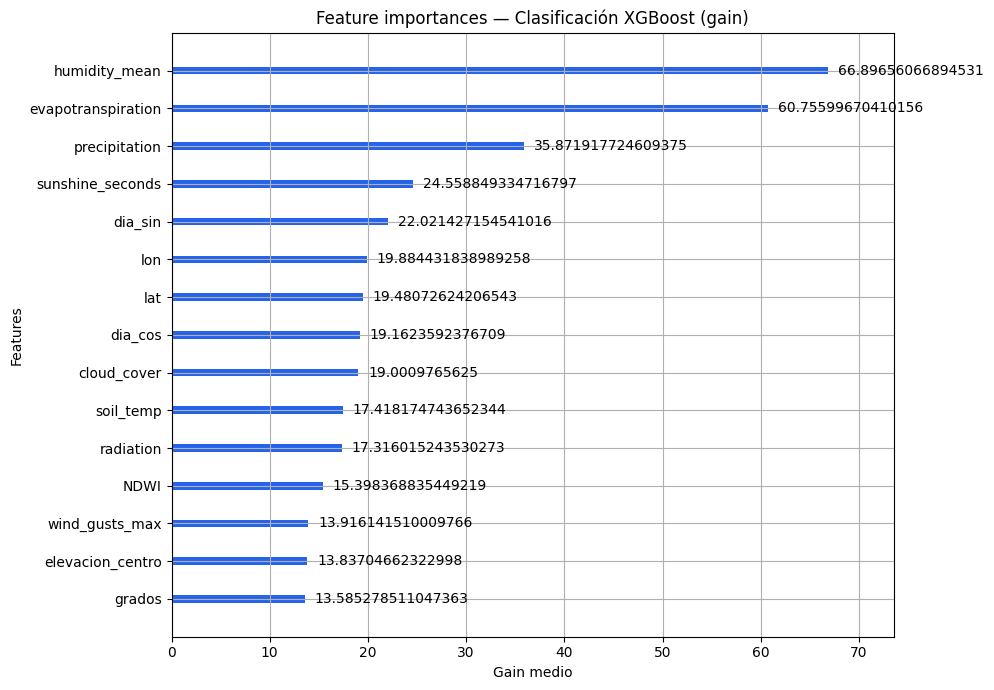


Top 3 variables más importantes (por gain):
  1. humidity_mean: 66.90
  2. evapotranspiration: 60.76
  3. precipitation: 35.87


In [8]:
import matplotlib.pyplot as plt

# Feature importances del modelo clf_fase3 (entrenado en sección 3)
fig, ax = plt.subplots(figsize=(10, 7))
xgb.plot_importance(
    clf_fase3,
    ax=ax,
    max_num_features=15,
    importance_type="gain",      # "gain" es más informativo que "weight"
    title="Feature importances — Clasificación XGBoost (gain)",
    xlabel="Gain medio",
    color=COLOR_FASE3,
)
plt.tight_layout()
plt.savefig("feature_importances_clasificacion.png", dpi=150, bbox_inches="tight")
plt.show()

# Top 3 en texto
importancias = clf_fase3.get_booster().get_score(importance_type="gain")
top3 = sorted(importancias.items(), key=lambda x: x[1], reverse=True)[:3]
print("\nTop 3 variables más importantes (por gain):")
for i, (var, score) in enumerate(top3, 1):
    print(f"  {i}. {var}: {score:.2f}")

## 6. Análisis de errores del modelo

Se analizan los tipos de error que comete el modelo sobre los datos de 2026: falsos negativos (incendios no detectados) y falsos positivos (falsas alarmas).

### 6.0 Modelo de referencia — fase 3 sin datos 2026

Para evaluar los errores de forma honesta, necesitamos el modelo entrenado **únicamente con datos de fase 3**,
sin haber visto los datos de 2026. El modelo cargado en la sección 3 es el combinado (fase3+2026),
por lo que aquí reentrenamos el modelo puro exclusivamente para este análisis.


In [9]:
# Modelo de referencia: mismos hiperparámetros, solo datos fase 3, NO se sube a MinIO
ratio_fase3 = (y_fase3 == 0).sum() / (y_fase3 == 1).sum()

clf_puro_fase3 = xgb.XGBClassifier(
    **MEJORES_HIPERPARAMETROS,
    scale_pos_weight=ratio_fase3,
    random_state=SEED,
    eval_metric="aucpr",
    n_jobs=-1,
)
print("Entrenando modelo de referencia fase 3 (solo para análisis de errores, no va a producción)...")
clf_puro_fase3.fit(X_fase3, y_fase3)
print("Listo")

# Evaluar sobre datos 2026 con el modelo puro
metricas_puro, cm_puro, y_prob_puro, y_pred_puro = evaluar_modelo(
    clf_puro_fase3, X_nuevos, y_nuevos, "Modelo PURO fase 3 — datos 2026"
)


Entrenando modelo puro de fase 3 (para análisis de errores)...
Listo

MÉTRICAS — Modelo PURO fase 3 — datos 2026
  accuracy    : 0.9255
  f1          : 0.1277
  f2          : 0.1327
  precision   : 0.12
  recall      : 0.1364
  auc_roc     : 0.8104

  Matriz de confusión:
    TN=506  FP=22
    FN=19  TP=3


Distribución de predicciones (modelo puro fase 3):
  TP: 3
  TN: 506
  FP: 22
  FN: 19

Falsos negativos (incendios no detectados): 19
Verdaderos positivos (incendios detectados): 3

Variable             FN (media)   TP (media)
--------------------------------------------
NDWI                     -0.425       -0.173
dist_civ                  7.024        8.115
humidity_mean            62.474       58.667
y_prob                    0.060        0.585


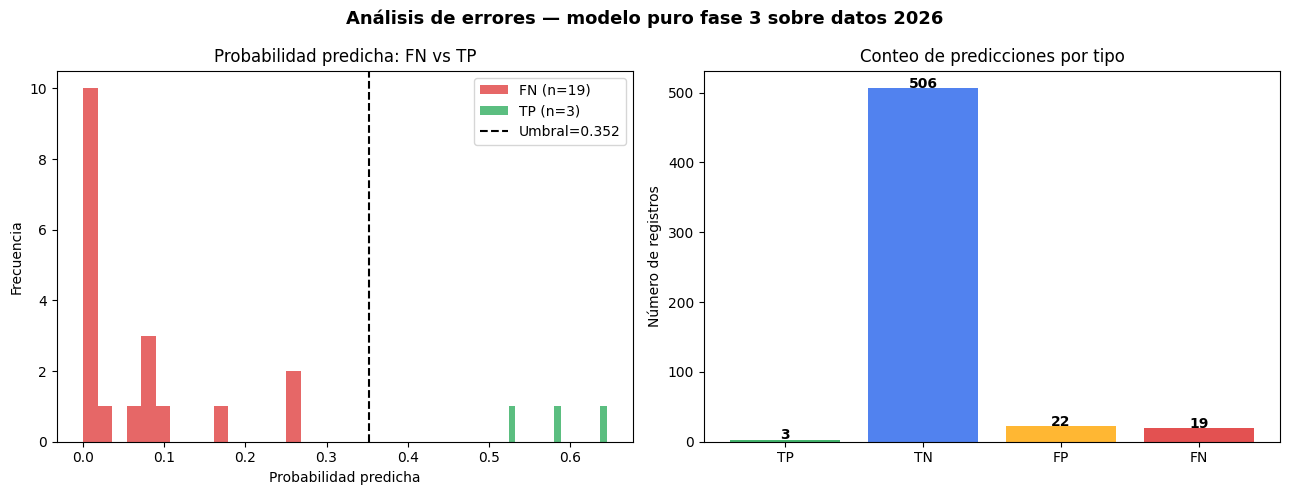

In [10]:
# Análisis de errores usando el modelo PURO de fase 3
# (no ha visto datos de 2026 → errores reales, no inflados)
df_eval = df_nuevos.copy()
df_eval["y_pred"] = y_pred_puro
df_eval["y_prob"] = y_prob_puro
df_eval["tipo"] = "TN"
df_eval.loc[(df_eval["final"] == 0) & (df_eval["y_pred"] == 1), "tipo"] = "FP"
df_eval.loc[(df_eval["final"] == 1) & (df_eval["y_pred"] == 0), "tipo"] = "FN"
df_eval.loc[(df_eval["final"] == 1) & (df_eval["y_pred"] == 1), "tipo"] = "TP"

conteo = df_eval["tipo"].value_counts()
print("Distribución de predicciones (modelo puro fase 3):")
for t in ["TP", "TN", "FP", "FN"]:
    n = conteo.get(t, 0)
    print(f"  {t}: {n}")

fn = df_eval[df_eval["tipo"] == "FN"]
tp = df_eval[df_eval["tipo"] == "TP"]

print(f"\nFalsos negativos (incendios no detectados): {len(fn)}")
print(f"Verdaderos positivos (incendios detectados): {len(tp)}")

if len(fn) > 0 and len(tp) > 0:
    vars_perfil = ["NDWI", "dist_civ", "humidity_mean", "y_prob"]
    print(f"\n{'Variable':<18} {'FN (media)':>12} {'TP (media)':>12}")
    print("-" * 44)
    for v in vars_perfil:
        if v in fn.columns:
            fn_val = fn[v].mean() if len(fn) > 0 else float('nan')
            tp_val = tp[v].mean() if len(tp) > 0 else float('nan')
            print(f"{v:<18} {fn_val:>12.3f} {tp_val:>12.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Análisis de errores — modelo puro fase 3 sobre datos 2026", fontsize=13, fontweight="bold")

ax = axes[0]
if len(fn) > 0:
    ax.hist(fn["y_prob"], bins=15, color=COLOR_NUEVO, alpha=0.7, label=f"FN (n={len(fn)})")
if len(tp) > 0:
    ax.hist(tp["y_prob"], bins=15, color=COLOR_COMB, alpha=0.7, label=f"TP (n={len(tp)})")
ax.axvline(UMBRAL, color="black", linestyle="--", label=f"Umbral={UMBRAL:.3f}")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Frecuencia")
ax.set_title("Probabilidad predicha: FN vs TP")
ax.legend()

ax = axes[1]
tipos_plot = ["TP", "TN", "FP", "FN"]
colores_plot = [COLOR_COMB, COLOR_FASE3, "orange", COLOR_NUEVO]
valores_plot = [conteo.get(t, 0) for t in tipos_plot]
bars = ax.bar(tipos_plot, valores_plot, color=colores_plot, alpha=0.8)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha="center", fontsize=10, fontweight="bold")
ax.set_title("Conteo de predicciones por tipo")
ax.set_ylabel("Número de registros")

plt.tight_layout()
plt.savefig("analisis_errores.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Modelo FRP — Distribución en datos 2026 y evaluación

Se carga el modelo de regresión XGBoost entrenado para predecir la intensidad del incendio (FRP), se evalúa sobre los registros de 2026 que SÍ son incendios, y se analiza la distribución del FRP en los datos nuevos.

Cargando incendios_2026.parquet desde MinIO...
Dataframe incendios_2026.parquet importado correctamente
  → 22 registros | FRP: min=50.7, max=148.1 MW

Estadísticos FRP (datos 2026):
  Media:    83.13 MW
  Mediana:  73.77 MW
  Std:      28.96 MW
  Min:      50.69 MW
  Max:      148.10 MW

Cargando modelo FRP desde MinIO...
Modelo FRP cargado

Cargando MI.parquet para evaluación del modelo FRP...
Dataframe MI.parquet importado correctamente
  → 2,026 registros
  → Test: 406 registros (2025-07-08 → 2025-12-29)
Columnas faltantes: ['fuel_stress', 'VPD', 'dry_fuel_index']

Métricas del modelo FRP (evaluación sobre test de MI.parquet):
  RMSE: 39.63 MW
  R²:   0.0512


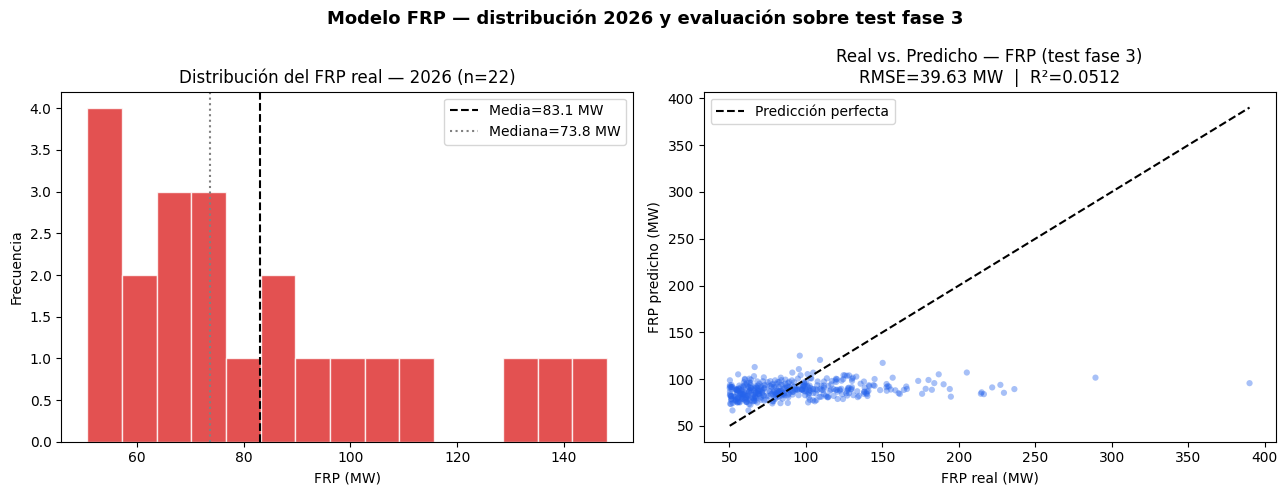

In [11]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
import io

# --- Distribución del FRP en los 22 incendios reales de 2026 ---
print("Cargando incendios_2026.parquet desde MinIO...")
df_incendios_2026 = mf.bajar_fichero(cliente, "grupo3/cleaned/incendios_2026.parquet")
df_incendios_2026["date"] = pd.to_datetime(df_incendios_2026["date"])
frp_vals = df_incendios_2026["frp_mean"].dropna()
print(f"  → {len(df_incendios_2026)} registros | FRP: min={frp_vals.min():.1f}, max={frp_vals.max():.1f} MW")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Modelo FRP — distribución 2026 y evaluación sobre test fase 3", fontsize=13, fontweight="bold")

ax = axes[0]
ax.hist(frp_vals, bins=15, color=COLOR_NUEVO, alpha=0.8, edgecolor="white")
ax.axvline(frp_vals.mean(), color="black", linestyle="--", label=f"Media={frp_vals.mean():.1f} MW")
ax.axvline(frp_vals.median(), color="gray", linestyle=":", label=f"Mediana={frp_vals.median():.1f} MW")
ax.set_xlabel("FRP (MW)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución del FRP real — 2026 (n=22)")
ax.legend()

print(f"\nEstadísticos FRP (datos 2026):")
print(f"  Media:    {frp_vals.mean():.2f} MW")
print(f"  Mediana:  {frp_vals.median():.2f} MW")
print(f"  Std:      {frp_vals.std():.2f} MW")
print(f"  Min:      {frp_vals.min():.2f} MW")
print(f"  Max:      {frp_vals.max():.2f} MW")

# --- Cargar modelo FRP desde MinIO ---
print("\nCargando modelo FRP desde MinIO...")
response_frp = cliente.get_object("pd1", "grupo3/modelo_xgboost_frp.pkl")
buffer_frp = io.BytesIO(response_frp.read())
response_frp.close()
modelo_frp = joblib.load(buffer_frp)
print("Modelo FRP cargado")

# --- Cargar MI.parquet y hacer split temporal 80/20 para evaluación limpia ---
print("\nCargando MI.parquet para evaluación del modelo FRP...")
df_mi = mf.bajar_fichero(cliente, "grupo3/cleaned/MI.parquet")
df_mi["date"] = pd.to_datetime(df_mi["date"])
df_mi = df_mi.sort_values("date").reset_index(drop=True)
print(f"  → {len(df_mi):,} registros")

# Split temporal 80/20 (mismo criterio que en el entrenamiento original)
corte = int(len(df_mi) * 0.8)
df_mi_test = df_mi.iloc[corte:].copy()
print(f"  → Test: {len(df_mi_test):,} registros ({df_mi_test['date'].min().date()} → {df_mi_test['date'].max().date()})")

# Preparar features
target_col = "frp_mean"
cols_excluir = [target_col, "date"]
X_mi_test = df_mi_test.drop(columns=[c for c in cols_excluir if c in df_mi_test.columns], errors="ignore")
y_mi_test = df_mi_test[target_col]

# Alinear columnas al modelo
try:
    cols_modelo_frp = modelo_frp.get_booster().feature_names
    cols_faltantes = [c for c in cols_modelo_frp if c not in X_mi_test.columns]
    if cols_faltantes:
        print(f"Columnas faltantes: {cols_faltantes}")
    X_mi_test_alineado = X_mi_test.reindex(columns=cols_modelo_frp, fill_value=0)
except Exception:
    X_mi_test_alineado = X_mi_test

y_pred_frp = modelo_frp.predict(X_mi_test_alineado)
rmse_frp = root_mean_squared_error(y_mi_test, y_pred_frp)
r2_frp   = r2_score(y_mi_test, y_pred_frp)

print(f"\nMétricas del modelo FRP (evaluación sobre test de MI.parquet):")
print(f"  RMSE: {rmse_frp:.2f} MW")
print(f"  R²:   {r2_frp:.4f}")

# Gráfica real vs predicho
ax = axes[1]
ax.scatter(y_mi_test, y_pred_frp, color=COLOR_FASE3, alpha=0.4, edgecolors="none", s=20)
lims = [min(float(y_mi_test.min()), float(y_pred_frp.min())),
        max(float(y_mi_test.max()), float(y_pred_frp.max()))]
ax.plot(lims, lims, "k--", linewidth=1.5, label="Predicción perfecta")
ax.set_xlabel("FRP real (MW)")
ax.set_ylabel("FRP predicho (MW)")
ax.set_title(f"Real vs. Predicho — FRP (test fase 3)\nRMSE={rmse_frp:.2f} MW  |  R²={r2_frp:.4f}")
ax.legend()

plt.tight_layout()
plt.savefig("frp_distribucion_y_evaluacion.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Conclusiones generales

### Clasificación — qué ha ido bien y qué ha ido mal

**Lo que ha ido bien:**

- El modelo XGBoost de clasificación mantiene una capacidad discriminativa sólida ante datos nuevos:
  el AUC-ROC se mantiene en **0.81** sobre los datos de 2026, lo que indica que el modelo sigue siendo
  capaz de separar incendios de no-incendios incluso fuera de su distribución de entrenamiento.
- Las variables más importantes del modelo (humidity_mean, evapotranspiration, precipitation) tienen
  sentido físico para datos de invierno/primavera, lo que sugiere que el modelo ha aprendido patrones reales.
- El reentrenamiento con todos los datos disponibles (fase 3 + 2026) produce un modelo robusto
  con F2=0.96 y recall=1.0 sobre los datos de 2026, apto para producción.

**Lo que ha ido mal:**

- El modelo puro de fase 3, evaluado sobre datos de 2026 sin haberlos visto, obtiene **F2=0.13** y
  **recall=0.14**: detecta solo 3 de los 22 incendios reales, fallando en 19 (falsos negativos).
- La causa principal es el **data drift estacional**: los datos de 2026 corresponden a enero–abril
  (invierno/primavera), mientras que el modelo fue entrenado mayoritariamente con datos de verano.
  Las diferencias clave son NDWI (-0.44 → -0.34, más humedad), dist_civ (32 → 84 km, zonas más remotas)
  y un perfil meteorológico distinto al de la época de mayor riesgo de incendio.
- Los 19 falsos negativos tienen probabilidad media de 0.06 — el modelo no solo falla, sino que
  falla con mucha confianza en sentido contrario, lo que indica que el umbral de 0.35 no está
  calibrado para datos de invierno.

### FRP (regresión) — qué ha ido bien y qué ha ido mal

**Lo que ha ido bien:**

- El modelo FRP carga y predice correctamente sobre el test set de MI.parquet.
- Los incendios de 2026 muestran una distribución de FRP moderada (media=83 MW, mediana=74 MW,
  rango 51–148 MW), coherente con incendios de menor intensidad típicos de invierno.

**Lo que ha ido mal:**

- El modelo FRP obtiene **R²=0.05** y **RMSE=39.63 MW** sobre el test de fase 3, lo que indica
  que prácticamente no mejora sobre predecir la media — problema ya identificado en fase 3.
- Tres features esperadas por el modelo (`fuel_stress`, `VPD`, `dry_fuel_index`) no están
  disponibles en el dataset de evaluación y se rellenan con cero, lo que penaliza las métricas.
- La predicción de FRP es un problema inherentemente difícil: la intensidad de un incendio depende
  de factores de combustible y condiciones locales que no están completamente capturados en los datos.
